# ResNet 18 Experiments

In [23]:
try:
    import medmnist
except ImportError:
    ! pip install -q medmnist
    import medmnist

import importlib
import helpers as h
importlib.reload(h)

from medmnist import DermaMNIST, INFO
import torch
from torchvision.transforms import v2 as transforms, Compose
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

print(medmnist.__version__)

3.0.2


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [4]:
# settings
DOWNLOAD = True
SIZE = 64
BATCH_SIZE = 64
NUM_WORKERS = 2

SEED = 912742984

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)

# print dataset info
info = INFO['dermamnist']

In [5]:
class_names = [info['label'][str(i)] for i in range(len(info['label']))]
class_names

['actinic keratoses and intraepithelial carcinoma',
 'basal cell carcinoma',
 'benign keratosis-like lesions',
 'dermatofibroma',
 'melanoma',
 'melanocytic nevi',
 'vascular lesions']

### ResNet 18

A baseline model: no data augmentation, train for 5 epochs

In [6]:
# transforms
basic_transform = Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = basic_transform)
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 100M/100M [00:06<00:00, 15.2MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]
100%|██████████| 16/16 [00:00<00:00, 63.33it/s]


Epoch 0 | Train loss: 0.8114, acc: 0.719 | Val loss: 0.6285, acc: 0.773, macro AUC: 0.924


100%|██████████| 16/16 [00:00<00:00, 68.31it/s]


Epoch 1 | Train loss: 0.6107, acc: 0.780 | Val loss: 0.9947, acc: 0.742, macro AUC: 0.895


...

100%|██████████| 16/16 [00:00<00:00, 59.76it/s]


Epoch 3 | Train loss: 0.4494, acc: 0.841 | Val loss: 0.5791, acc: 0.802, macro AUC: 0.946


100%|██████████| 16/16 [00:00<00:00, 66.03it/s]


Epoch 4 | Train loss: 0.3676, acc: 0.865 | Val loss: 0.6752, acc: 0.789, macro AUC: 0.934


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

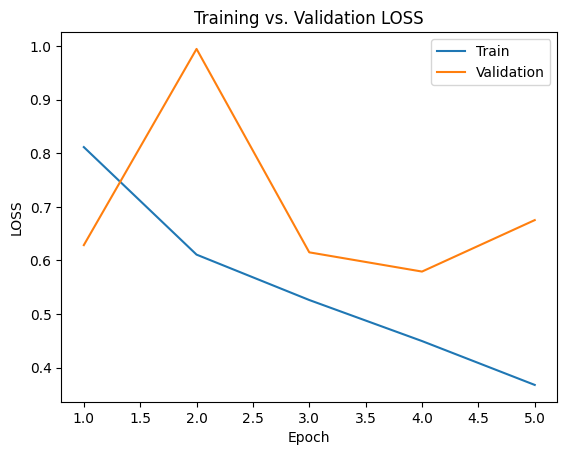

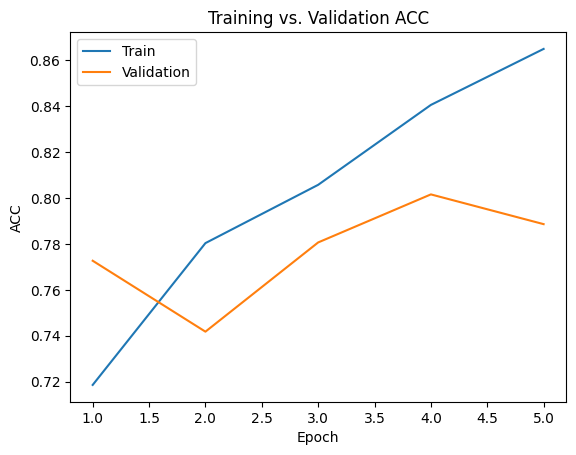

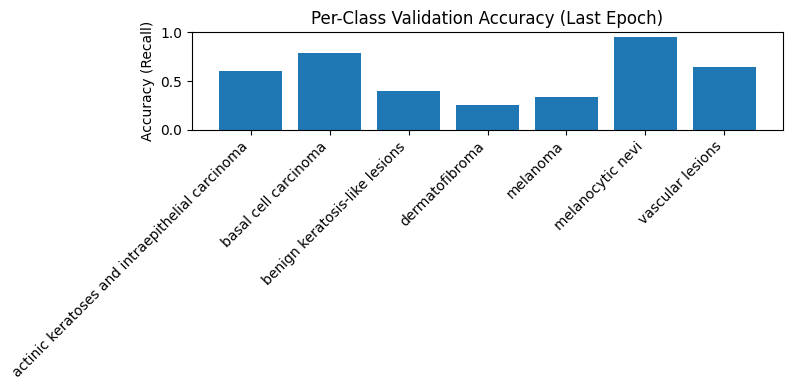

In [7]:
# create a fresh model (for reproducibility)
model = h.create_resnet(size=18)

# freeze all layers except classifier - not doing this anymore, since just training classifier doesn't work well
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history_model1 = h.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

h.plot_train_hist(train_history_model1, type='loss')
h.plot_train_hist(train_history_model1, type='acc')
h.plot_per_class_accuracy(train_history_model1, class_names=class_names)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

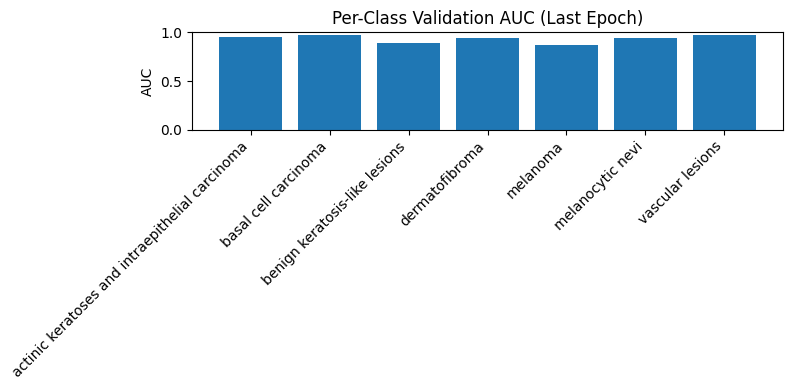

In [8]:
h.plot_per_class_auc(train_history_model1, class_names)

In [9]:
print("Final AUC:")
print(h.compute_auc(model, val_loader, device))

print("Final validation accuracy:")
print(train_history_model1['val_acc'][-1])

Final AUC:


100%|██████████| 16/16 [00:00<00:00, 68.44it/s]

0.9336259570280923
Final validation accuracy:
0.7886340977068793


The baseline AUC is 0.92 and the baseline accuracy is 0.754. This model already beats both of them!

However, I will experiment more to see how high I can get it.

While the model looks like it is overfitting, let's see if that is a fluke by training for more epochs.

100%|██████████| 16/16 [00:00<00:00, 62.00it/s]


Epoch 0 | Train loss: 0.8205, acc: 0.717 | Val loss: 0.6674, acc: 0.759, macro AUC: 0.930


100%|██████████| 16/16 [00:00<00:00, 66.43it/s]


Epoch 1 | Train loss: 0.5935, acc: 0.781 | Val loss: 0.6595, acc: 0.763, macro AUC: 0.927


100%|██████████| 16/16 [00:00<00:00, 65.30it/s]


...

100%|██████████| 16/16 [00:00<00:00, 66.65it/s]


Epoch 14 | Train loss: 0.0866, acc: 0.969 | Val loss: 1.0455, acc: 0.778, macro AUC: 0.935
Final AUC:


100%|██████████| 16/16 [00:00<00:00, 64.10it/s]

0.9352250389134668
Final validation accuracy:
0.7776669990029911


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

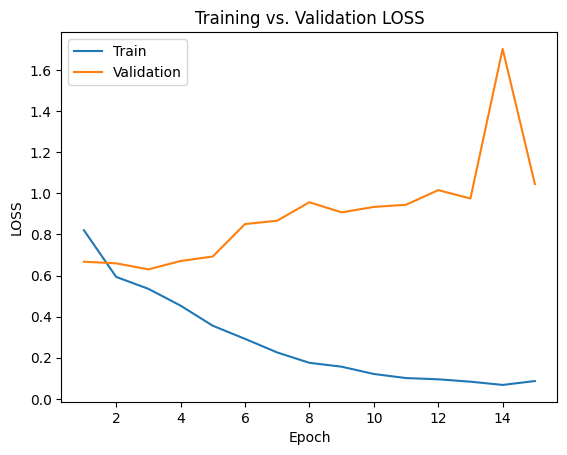

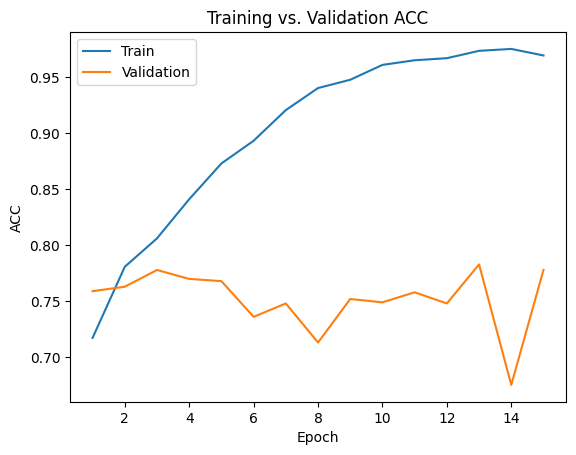

In [10]:
# longer epochs trained

NUM_EPOCHS = 15

model = h.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

print("Final AUC:")
print(h.compute_auc(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])
h.plot_train_hist(train_history, type='loss')
h.plot_train_hist(train_history, type='acc')

That is definitely overfitting. There is no point in training beyond 5 epochs, so let's go with that.

Now, I will test data augmentation.

**AI Usage:** I asked ChatGPT to suggest some data augmentations I can do for dermatoscope images. I also asked it to generate PyTorch code for the augmentations it suggested (in the variable `data_augmentation_1`). This code is used below. I also uploaded the sample images back to ChatGPT and asked it to refine the data augmentations in follow-up prompts.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


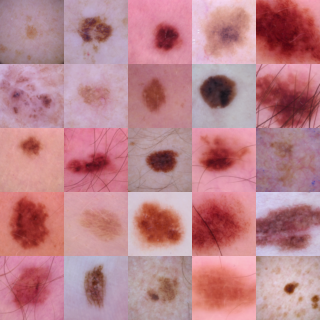

In [11]:
# data augmentations to test
data_augmentation_1 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    transforms.ColorJitter(
        brightness=0.05,            # ±5%
        contrast=0.05,              # ±5%
        saturation=0.05,            # ±5%
        hue=0.01                    # very small hue shift
    ),

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [12]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_1))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

100%|██████████| 16/16 [00:00<00:00, 66.55it/s]


Epoch 0 | Train loss: 0.8919, acc: 0.694 | Val loss: 0.7644, acc: 0.743, macro AUC: 0.863


100%|██████████| 16/16 [00:00<00:00, 64.96it/s]


Epoch 1 | Train loss: 0.7267, acc: 0.740 | Val loss: 0.6614, acc: 0.761, macro AUC: 0.922


100%|██████████| 16/16 [00:00<00:00, 64.83it/s]


...

Epoch 27 | Train loss: 0.4809, acc: 0.821 | Val loss: 0.5381, acc: 0.803, macro AUC: 0.952


100%|██████████| 16/16 [00:00<00:00, 64.91it/s]


Epoch 28 | Train loss: 0.4846, acc: 0.817 | Val loss: 0.5871, acc: 0.782, macro AUC: 0.945


100%|██████████| 16/16 [00:00<00:00, 65.79it/s]

Epoch 29 | Train loss: 0.4706, acc: 0.824 | Val loss: 0.5482, acc: 0.799, macro AUC: 0.948


Final AUC:


100%|██████████| 16/16 [00:00<00:00, 65.11it/s]


0.9482901367951911
Final validation accuracy:
0.7986041874376869


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

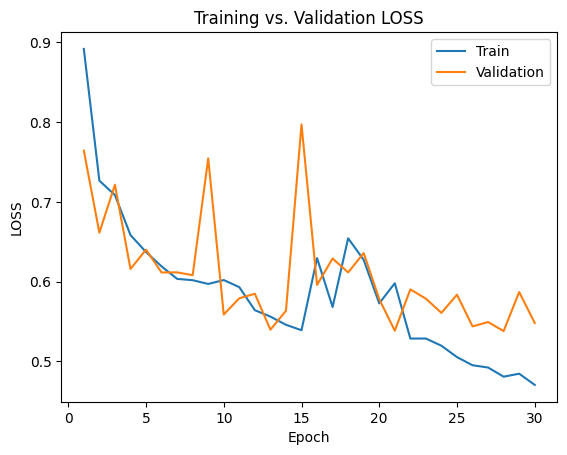

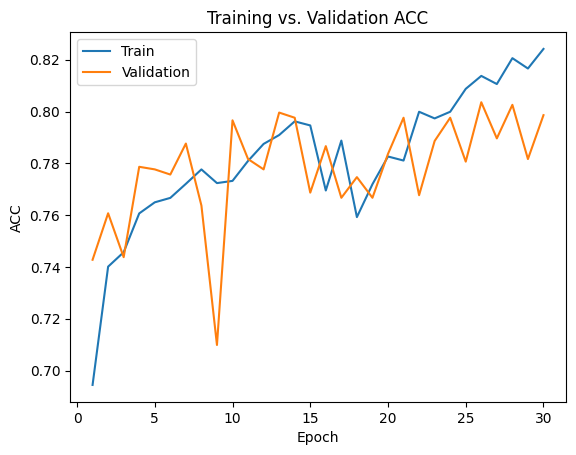

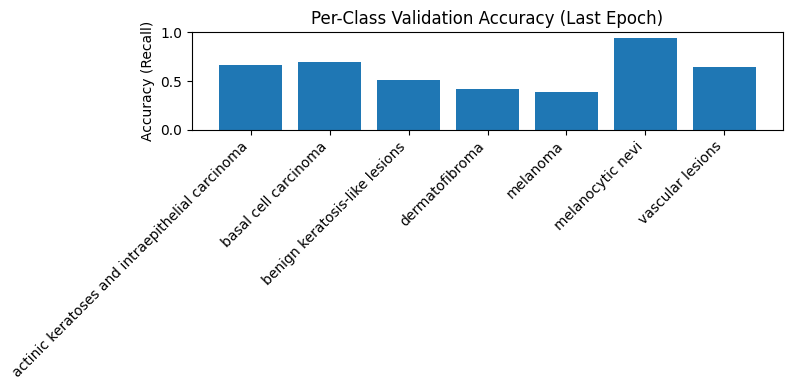

In [13]:
print("Final AUC:")
print(h.compute_auc(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.plot_train_hist(train_history, type='loss')
h.plot_train_hist(train_history, type='acc')

h.plot_per_class_accuracy(train_history, class_names)

On these, it did not seem to overfit on 5 or 10 epochs.

It seems to start overfitting at around 25 epochs or so.

Let's try changing the augmentations a little.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


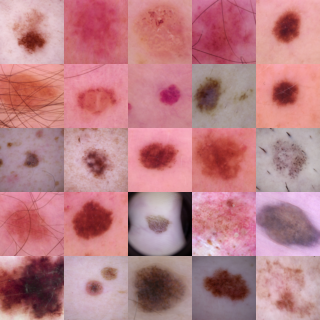

In [14]:
# data augmentations to test
data_augmentation_2 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    transforms.RandomResizedCrop(
        size=64,
        scale=(0.95, 1.0),          # only small crops
        ratio=(0.95, 1.05)
    ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    # BYE BYE!

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_2))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [15]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_2))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)


100%|██████████| 16/16 [00:00<00:00, 64.12it/s]


Epoch 0 | Train loss: 0.8574, acc: 0.702 | Val loss: 0.7322, acc: 0.732, macro AUC: 0.908


100%|██████████| 16/16 [00:00<00:00, 65.52it/s]


Epoch 1 | Train loss: 0.7007, acc: 0.750 | Val loss: 0.6305, acc: 0.767, macro AUC: 0.935


100%|██████████| 16/16 [00:00<00:00, 64.71it/s]


...

Epoch 27 | Train loss: 0.4503, acc: 0.832 | Val loss: 0.6061, acc: 0.789, macro AUC: 0.945


100%|██████████| 16/16 [00:00<00:00, 65.65it/s]


Epoch 28 | Train loss: 0.4335, acc: 0.835 | Val loss: 0.5584, acc: 0.795, macro AUC: 0.951


100%|██████████| 16/16 [00:00<00:00, 66.40it/s]

Epoch 29 | Train loss: 0.4334, acc: 0.836 | Val loss: 0.5990, acc: 0.780, macro AUC: 0.950


Final AUC:


100%|██████████| 16/16 [00:00<00:00, 65.79it/s]


0.9499348880687054
Final validation accuracy:
0.7796610169491526


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

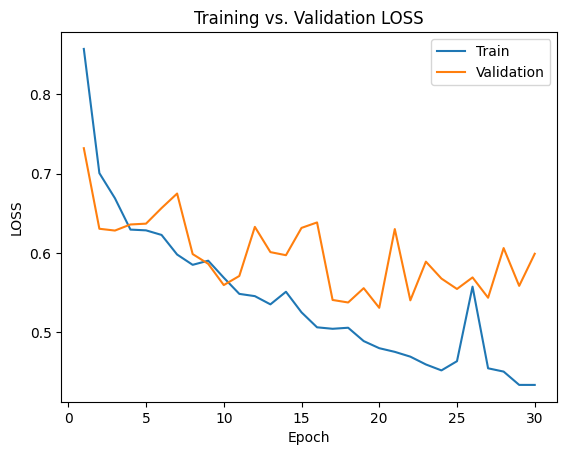

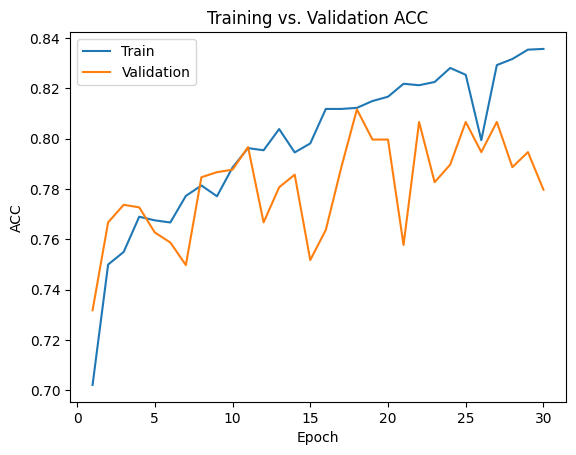

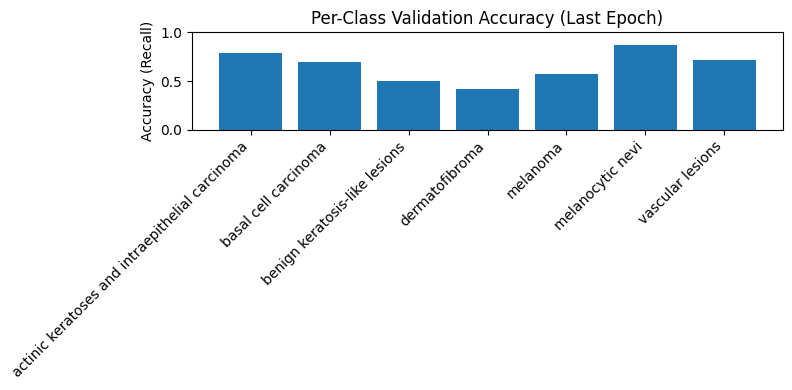

In [16]:
print("Final AUC:")
print(h.compute_auc(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.plot_train_hist(train_history, type='loss')
h.plot_train_hist(train_history, type='acc')

h.plot_per_class_accuracy(train_history, class_names)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


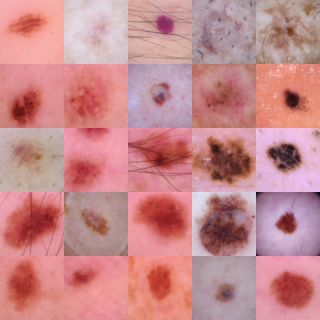

In [17]:
# data augmentations to test
data_augmentation_3 = [
    # --- Geometric transforms ---
    transforms.RandomRotation(
        degrees=180  # 0–180°; you can make it 360 if you want
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    # Small translation + zoom, no shear
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),     # up to 5% shift
        scale=(0.95, 1.05),         # milder zoom ±5%
        shear=0
    ),

    # Option 1: very mild crop (keep most of lesion)
    # transforms.RandomResizedCrop(
    #     size=64,
    #     scale=(0.95, 1.0),          # only small crops
    #     ratio=(0.95, 1.05)
    # ),
    # Option 2: if lesions are already centered, comment the above out

    # --- Photometric / color transforms ---
    # BYE BYE!

    # Mild Gaussian blur, lower prob & sigma for 64x64
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))],
        p=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
]

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_ds.montage(5)

In [18]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 30

model = h.create_resnet(size=18)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history = h.train_model(
    model, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)


100%|██████████| 16/16 [00:00<00:00, 28.30it/s]


Epoch 0 | Train loss: 0.8691, acc: 0.705 | Val loss: 0.7219, acc: 0.738, macro AUC: 0.922


100%|██████████| 16/16 [00:00<00:00, 28.57it/s]


Epoch 1 | Train loss: 0.6806, acc: 0.750 | Val loss: 0.6756, acc: 0.751, macro AUC: 0.927


100%|██████████| 16/16 [00:00<00:00, 27.53it/s]


...

Epoch 27 | Train loss: 0.4411, acc: 0.830 | Val loss: 0.6295, acc: 0.779, macro AUC: 0.943


100%|██████████| 16/16 [00:00<00:00, 26.71it/s]


Epoch 28 | Train loss: 0.4219, acc: 0.839 | Val loss: 0.6198, acc: 0.803, macro AUC: 0.942


100%|██████████| 16/16 [00:00<00:00, 27.36it/s]

Epoch 29 | Train loss: 0.4187, acc: 0.837 | Val loss: 0.7116, acc: 0.788, macro AUC: 0.936


Final AUC:


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 27.40it/s]

0.9364248347086275
Final validation accuracy:
0.7876370887337986


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

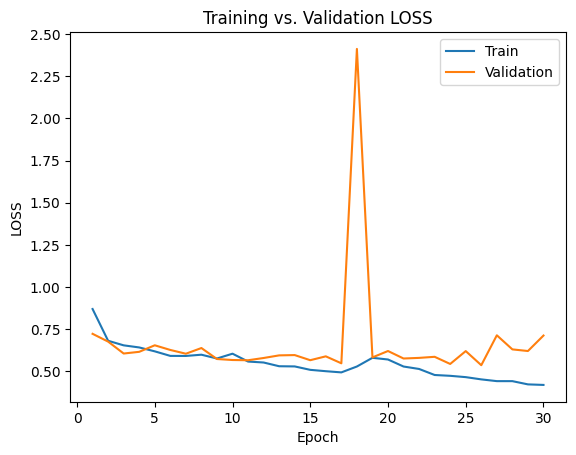

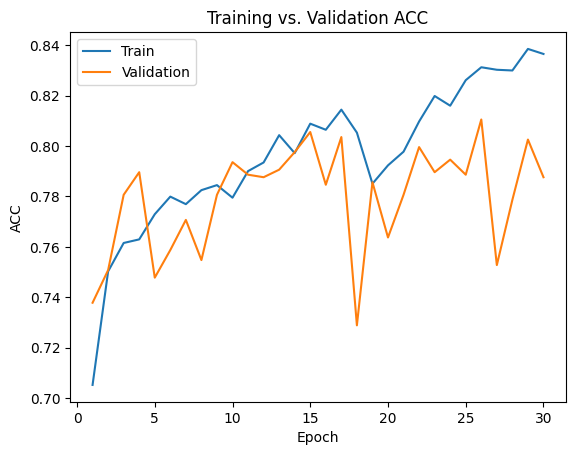

In [19]:
print("Final AUC:")
print(h.compute_auc(model, val_loader, device))

print("Final validation accuracy:")
print(train_history['val_acc'][-1])

h.plot_train_hist(train_history, type='loss')
h.plot_train_hist(train_history, type='acc')

Between all those data augmentations, it seems to be performing about the same.

Let's try adding attention.

In [28]:
# data aug

train_ds = DermaMNIST(split='train', download=DOWNLOAD, size=SIZE, mmap_mode='r', transform = Compose(data_augmentation_3))
val_ds = DermaMNIST(split='val', download=DOWNLOAD, size=SIZE, transform=basic_transform)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_EPOCHS = 60

model_se = h.create_resnet(size=18, use_se=True)

# freeze all layers except classifier
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True

train_history_se = h.train_model(
    model_se, 
    train_loader,
    val_loader,
    optimizer=torch.optim.Adam(model_se.parameters(), lr=LEARNING_RATE),
    criterion=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS,
    device=device,
)

100%|██████████| 16/16 [00:00<00:00, 60.42it/s]


Epoch 0 | Train loss: 0.8156, acc: 0.705 | Val loss: 0.6880, acc: 0.734, macro AUC: 0.918


100%|██████████| 16/16 [00:00<00:00, 55.22it/s]


Epoch 1 | Train loss: 0.6788, acc: 0.752 | Val loss: 0.7305, acc: 0.712, macro AUC: 0.919


100%|██████████| 16/16 [00:00<00:00, 54.46it/s]


...

Epoch 57 | Train loss: 0.1887, acc: 0.925 | Val loss: 0.7118, acc: 0.812, macro AUC: 0.950


100%|██████████| 16/16 [00:00<00:00, 55.58it/s]


Epoch 58 | Train loss: 0.1967, acc: 0.926 | Val loss: 0.6849, acc: 0.781, macro AUC: 0.948


100%|██████████| 16/16 [00:00<00:00, 62.61it/s]

Epoch 59 | Train loss: 0.1779, acc: 0.932 | Val loss: 0.7170, acc: 0.812, macro AUC: 0.951


Final AUC:


100%|██████████| 16/16 [00:00<00:00, 60.77it/s]

0.9508085692455683
Final validation accuracy:
0.8115653040877367


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

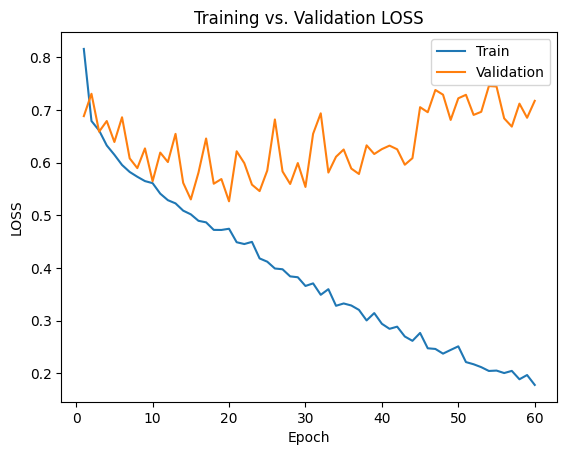

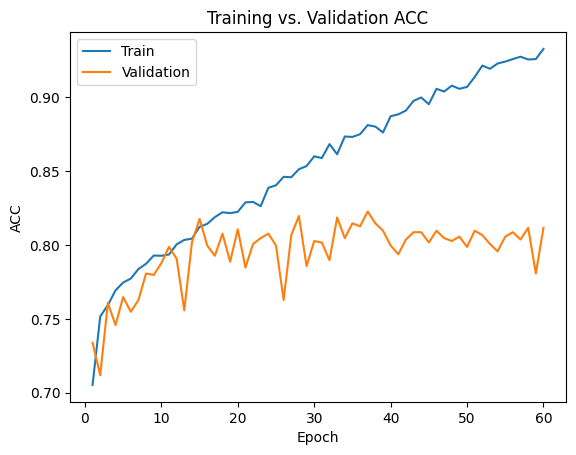

In [29]:
print("Final AUC:")
print(h.compute_auc(model_se, val_loader, device))

print("Final validation accuracy:")
print(train_history_se['val_acc'][-1])

h.plot_train_hist(train_history_se, type='loss')
h.plot_train_hist(train_history_se, type='acc')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

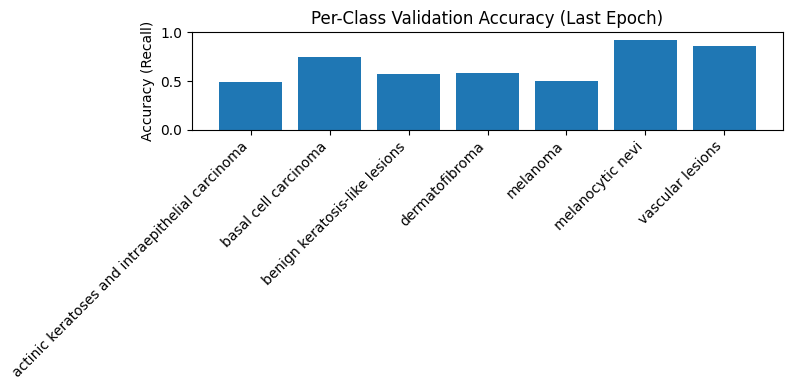

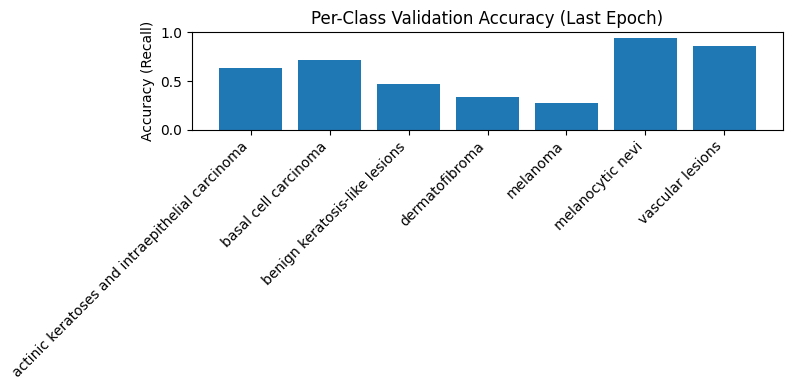

In [32]:
h.plot_per_class_accuracy(train_history_se, class_names)
h.plot_per_class_accuracy(train_history, class_names)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

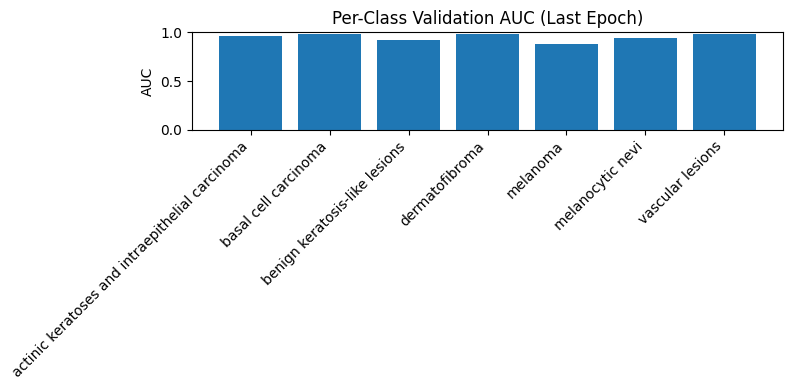

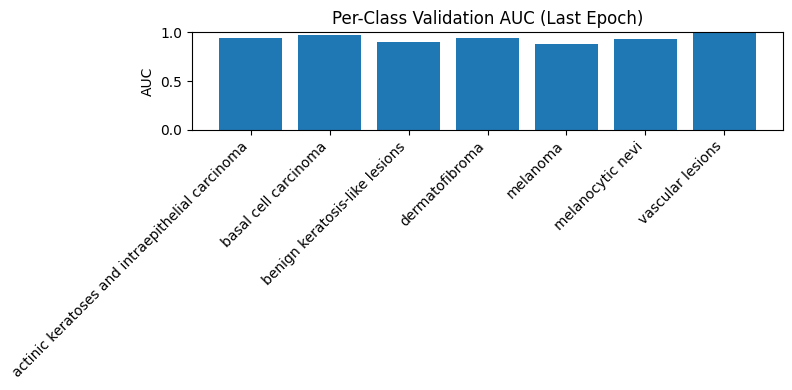

In [33]:
h.plot_per_class_auc(train_history_se, class_names)
h.plot_per_class_auc(train_history, class_names)